# HySwash: A hybrid framework for nearshore wave modeling

In the previous notebook, we created and exported a bathymetric profile for SWASH.

In this notebook, we will use that profile to build a **HySwash case**, run SWASH,
and explore how waves propagate from offshore to the coast.

## What is HySwash?

**HySwash** is a hybrid modeling framework that combines physics-based SWASH
simulations with surrogate modeling to efficiently reproduce nearshore wave
transformation.

Here, we will first focus on the **physics-based component** of the framework:
setting up and running SWASH for a single set of offshore wave conditions.

**References:**  
> * Ricondo et al. (2024). *HySwash: A hybrid model for nearshore wave processes*. **Ocean Engineering**, 
> [https://doi.org/10.1016/j.oceaneng.2023.116419](https://doi.org/10.1016/j.oceaneng.2023.116419)

> * Ricondo et al. (2024). *Introducing bimodal sea-states in a hybrid model for nearshore wave processes*. **Coastal Engineering**, 
> [https://doi.org/10.1016/j.coastaleng.2024.104556](https://doi.org/10.1016/j.coastaleng.2024.104556)

In [2]:
import os
import os.path as op
import sys

import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import xarray as xr
from IPython.display import HTML

sys.path.insert(0, "..")

from utils.boundary_conditions import get_real_scenarios_from_dataset
from utils.plotting import (
    animate_case_propagation,
    plot_depthfile,
    plot_scatters_Tp,
    steepness_to_Tp,
)

In [3]:
root_dir = os.getcwd()

output_dir = op.join(root_dir, "output")
templates_dir = op.join(root_dir, "templates")
export_dir = op.join(root_dir, "export")

os.makedirs(export_dir, exist_ok=True)

## Load the bathymetry

We will start from the bathymetric profile exported in the previous notebook.

The profile is stored in `templates/depth.bot`, which contains one water-depth
value per computational node.

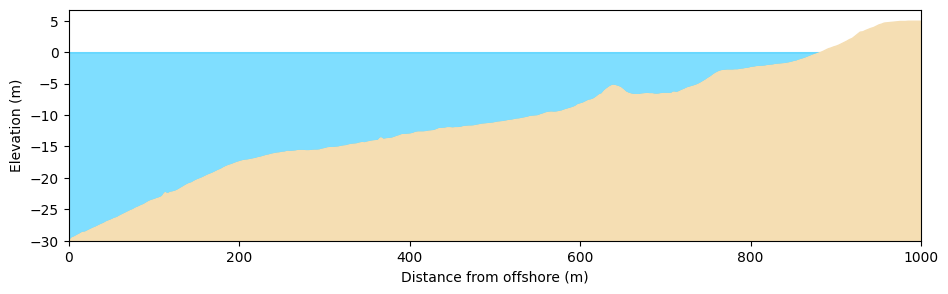

In [4]:
depth_file = op.join(templates_dir, "depth.bot")
depth_array = np.loadtxt(depth_file)

plot_depthfile(depth_array)
plt.show()

## 1. Define offshore wave conditions

To build a HySwash surrogate model, we need a set of SWASH simulations that
represent different offshore wave conditions.

Rather than selecting these conditions randomly, we use **Latin Hypercube
Sampling (LHS)** to efficiently explore the range of possible wave conditions.

### 1.1. Latin Hypercube Sampling (LHS)

Latin Hypercube Sampling (LHS) is a sampling method designed to efficiently
explore a multidimensional parameter space.

Each variable is divided into equally probable intervals, and samples are drawn
so that every interval is represented once. This provides a more uniform
coverage of the parameter space than purely random sampling.

To generate the HySwash training cases, we first define the range of values
allowed for each offshore wave parameter.

We sample three variables describing the offshore wave and water-level
conditions at the offshore boundary of the profile (~30 m depth). The ranges
cover the historical conditions we will reconstruct in the next notebook:
waves from **BinWaves** at this point and water levels from the **South Beach
tide gauge** (2020), referred to their mean.

| Variable | Description | Range |
|:---------|:------------|:-----:|
| `Hs` | Significant wave height | 0.3–7.0 m |
| `Hs_L0` | Wave steepness | 0.0007–0.03 |
| `WL` | Water level | -2.2–2.2 m |

We generate **10,000 combinations** within these ranges using LHS.

In [5]:
from bluemath_tk.datamining.lhs import LHS

variables = ["Hs", "Hs_L0", "WL"]

lhs = LHS(num_dimensions=len(variables))

lhs_dataset = lhs.generate(
    dimensions_names=variables,
    lower_bounds=[0.3, 0.0007, -2.2],
    upper_bounds=[7.0, 0.03, 2.2],
    num_samples=10_000,
)

lhs_dataset

,Hs,Hs_L0,WL
0,3.246987,0.008638,1.942097
1,6.045284,0.006357,-1.248906
2,4.066855,0.014666,-1.849562
3,4.566542,0.002426,0.697603
4,5.816559,0.015515,0.031987
...,...,...,...
9995,1.401704,0.009026,1.555890
9996,1.402608,0.003290,0.297753
9997,0.493680,0.020649,0.536428
9998,0.679141,0.029064,2.176146


### Convert the samples to wave conditions

The LHS samples `Hs`, wave steepness (`Hs_L0`), and water level (`WL`), but SWASH
requires the corresponding wave-period information.

We therefore transform the sampled parameter combinations into physically
consistent offshore wave conditions for the selected water depth.

In [6]:
h0 = depth_array[0]

# Keep realistic periods: the historical Tp at this point is below ~23 s
df_dataset = get_real_scenarios_from_dataset(lhs_dataset, h0, tp_min=7, tp_max=25)
df_dataset.to_pickle(op.join(export_dir, "lhs_dataset.pkl"))

### 1.2. Maximum Dissimilarity Algorithm (MDA)

The LHS provides a large set of offshore wave conditions, but running SWASH for
all of them would be computationally expensive.

To reduce the number of simulations, we use the **Maximum Dissimilarity
Algorithm (MDA)** ([Camus et al., 2011](REFERENCE)), which selects a smaller set
of representative cases while preserving the diversity of the original
parameter space.

Starting from an initial case, MDA iteratively selects the condition that is
most dissimilar from those already selected. The process continues until the
desired number of representative cases is reached.

In HySwash, these selected cases define the **SWASH simulations used to build
the surrogate model**.

Conceptually, MDA performs the following iterative selection:

**initial case → find the most dissimilar case → add it to the subset → repeat**

In [7]:
from bluemath_tk.datamining.mda import MDA

mda_samples = 10

mda = MDA(num_centers=mda_samples)
mda.fit(data=df_dataset, normalize_data=True)

The MDA has now selected `mda_samples` representative conditions from the original
parameter space. Let's visualize where these cases are located relative to
the full dataset.

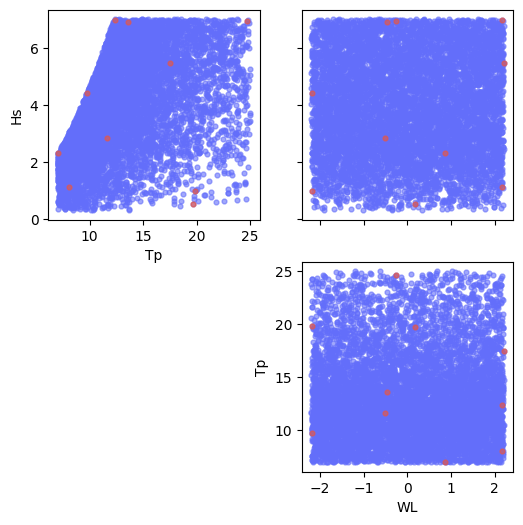

In [8]:
# MDA works with Hs_L0, but we display the peak period Tp instead
fig, axes = plot_scatters_Tp(
    mda.centroids,
    mda.data,
    s=12,
    data_colors=px.colors.qualitative.Plotly[:2],
)

fig.set_size_inches(6, 6)
plt.show()

### Export the MDA model

We save the fitted MDA model so that the selected representative cases can be
reused in the next notebook.

In [9]:
mda._exclude_attributes = []

mda.save_model(
    model_path=op.join(export_dir, "mda_model.pkl"),
)

## 2. Numerical model: SWASH

Now that the representative wave conditions have been selected with MDA, we
will simulate each case using **SWASH**.

SWASH is a **non-hydrostatic, phase-resolving numerical model** for simulating
wave transformation from offshore waters to the shoreline. It can represent
processes such as **wave breaking, bottom friction, wave-induced setup and
runup, and infragravity-wave generation and propagation**.

In HySwash, SWASH provides the physics-based simulations used to train the
surrogate model.

For a detailed description of the model configuration and available commands,
see the [SWASH User Manual](https://swash.sourceforge.io/download/zip/swashuse.pdf).

### 2.2. Configure the SWASH simulations

We now create the `HySwashModelWrapper`, which connects the representative
conditions selected by MDA with the SWASH numerical model.

The wrapper combines:

- the **MDA-selected wave conditions** that vary between simulations,
- the **bathymetry** exported in the previous notebook, and
- a set of **fixed numerical parameters** shared by all SWASH simulations.

These settings are used to automatically generate the SWASH input files for
each case.

In [10]:
from utils.hyswash_wrapper import HySwashModelWrapper

metamodel_parameters = mda.centroids.to_dict(orient="list")

fixed_parameters = {
    "dxinp": 1,
    "comptime": 300,
    "warmup": 150,
    "n_nodes_per_wavelength": 100,
    "Cf_ini": 0,
    "Cf_fin": 900,
    "Cf": 0.02,
}

swash_model = HySwashModelWrapper(
    templates_dir=templates_dir,
    templates_name=["INPUT", "depth.bot"],
    output_dir=output_dir,
    depth_array=depth_array,
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
)

### 2.3. Build and run the SWASH cases

The HySwash wrapper can now generate and execute the SWASH simulations for the
representative conditions selected by MDA.

We will proceed in three steps:

**build the cases → launch the simulations → monitor their progress**

In [11]:
swash_model.build_cases()

In [12]:
swash_model.run_cases_in_background(launcher='serial', num_workers=2)

In [14]:
swash_model.monitor_cases()

,Case,Status
0,0000,END
1,0001,END
2,0002,END
3,0003,END
4,0004,END
5,0005,END
6,0006,END
7,0007,END
8,0008,END
9,0009,END


## 3. Data processing

Once the SWASH simulations are complete, we can postprocess the raw model
outputs to derive quantities that describe nearshore wave transformation.

HySwash can compute variables related to **wave height, frequency-band
contributions, wave setup, and runup**.

First, let's check which variables are available for postprocessing.


In [15]:
swash_model.list_available_postprocess_vars()

['Ru2', 'Runlev', 'Msetup', 'Hrms', 'Hfreqs']

The HySwash postprocessor provides the following derived variables:

| Variable | Description | Units |
|:---------|:------------|:-----:|
| `Ru2` | 2% exceedance wave runup height | m |
| `Runlev` | Time-dependent wave runup level along the cross-shore profile | m |
| `Msetup` | Mean wave-induced water-level setup along the cross-shore profile | m |
| `Hrms` | Root-mean-square wave height along the cross-shore profile | m |
| `Hfreqs` | Wave-height contributions computed for different frequency bands | m |

`Hfreqs` separates the wave signal into three frequency bands:

| Component | Description | Frequency range |
|:----------|:------------|:---------------:|
| `Hs` | Incident-wave component | 0.04–1 Hz |
| `Hig` | Infragravity-wave component | 0.004–0.04 Hz |
| `Hvlf` | Very-low-frequency component | 0.001–0.004 Hz |

We will now postprocess all simulated cases and combine their results into a
single `xarray.Dataset`.

In [16]:
postprocessed_output = swash_model.postprocess_cases(write_output_nc=True)
postprocessed_output

<xarray.Dataset> Size: 528kB
Dimensions:   (case_num: 10, Tsec: 451, Xp: 1001)
Coordinates:
  * case_num  (case_num) int64 80B 0 1 2 3 4 5 6 7 8 9
  * Tsec      (Tsec) int64 4kB 0 1 2 3 4 5 6 7 ... 444 445 446 447 448 449 450
  * Xp        (Xp) int64 8kB 0 1 2 3 4 5 6 7 ... 994 995 996 997 998 999 1000
Data variables:
    Ru2       (case_num) float64 80B 2.894 0.6836 2.488 ... 2.85 5.449 0.7636
    Runlev    (case_num, Tsec) float64 36kB 0.0 0.0 0.0 ... -0.2364 -0.0866 nan
    Msetup    (case_num, Xp) float64 80kB 0.198 0.1855 0.1704 ... nan nan nan
    Hrms      (case_num, Xp) float64 80kB 7.179 7.165 7.131 ... nan nan nan
    Hs        (case_num, Xp) float64 80kB 10.17 10.15 10.1 10.03 ... nan nan nan
    Hss       (case_num, Xp) float64 80kB 10.16 10.14 10.08 ... nan nan nan
    Hig       (case_num, Xp) float64 80kB 0.5751 0.5858 0.585 ... nan nan nan
    Hvlf      (case_num, Xp) float64 80kB 0.1845 0.1901 0.1994 ... nan nan nan

### 3.1. Explore the postprocessed results

Let's visualize how the postprocessed wave quantities vary across the
cross-shore profile and compare the different SWASH cases.

Choose a variable (`Runlev`, `Msetup`, `Hrms`, `Hs`, `Hig`, or `Hvlf`) and the
cases you want to visualize.

> `Hs`, `Hig`, and `Hvlf` correspond to the frequency-band components stored
> within `Hfreqs`.

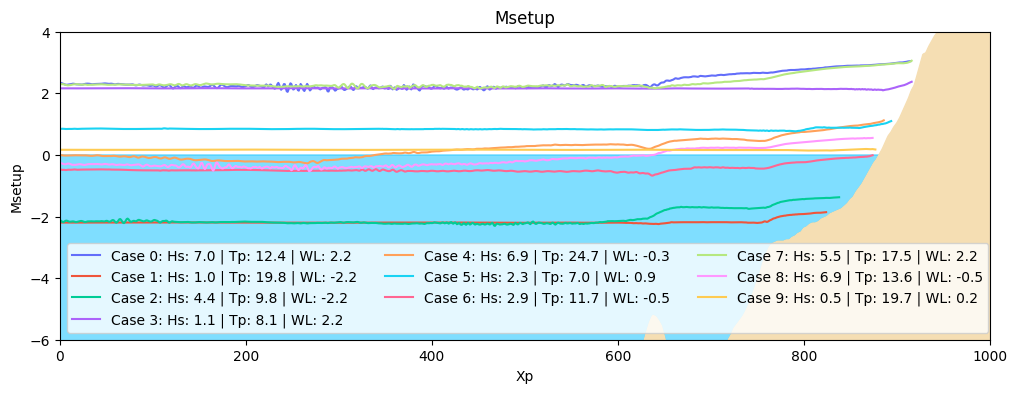

In [17]:
postprocessed_var = "Msetup"
cases = postprocessed_output.case_num.values
centroids_Tp = steepness_to_Tp(mda.centroids)  # display Tp instead of Hs_L0

fig, ax = plt.subplots(figsize=(12, 4))
plot_depthfile(depth_array, ax=ax)

for case_num in cases:
    values = centroids_Tp.iloc[case_num]
    data = postprocessed_output[postprocessed_var].sel(case_num=case_num)

    if postprocessed_var == "Msetup":
        data = data + values["WL"]

    data.plot(
        ax=ax,
        color=px.colors.qualitative.Plotly[case_num % 10],
        label=f"Case {case_num}: "
        + " | ".join(f"{k}: {v:.1f}" for k, v in values.items()),
    )

ax.set_ylim(-6, 4)
ax.set_title(postprocessed_var)
ax.legend(ncols=3)
plt.show()

### Total Water Elevation Visualization
Fill case_num with the number of the simulation you want to visualize



In [18]:
case_num = 0

case_num_s = str(case_num).zfill(4)
output_nc = xr.open_dataset(op.join(output_dir, case_num_s, "output.nc"))
data = output_nc[["Watlev"]].squeeze()
ani = animate_case_propagation(
    data,
    depth_array + mda.centroids.iloc[case_num]["WL"],
    tini=0,
    tend=300,
    tstep=5,
    figsize=(11, 3),
)
HTML(ani.to_jshtml())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


## Summary

In this notebook, we:

- Generated a large set of offshore wave conditions using **Latin Hypercube Sampling (LHS)**.
- Selected a smaller set of representative conditions using the **Maximum Dissimilarity Algorithm (MDA)**.
- Configured and ran **SWASH simulations** for the selected cases using the HySwash wrapper.
- Postprocessed the SWASH outputs to obtain quantities such as **wave heights, wave setup, and runup**.
- Explored the cross-shore transformation of these quantities and visualized **wave propagation through time**.

## What's next?

Running SWASH for many different offshore conditions can become computationally expensive.

In the next notebook, we will use the SWASH simulations generated here to train a **surrogate model** that can efficiently predict nearshore wave conditions without running a new SWASH simulation for every case.